# House Prices: clasificación binaria, comparación de modelos y optimización con GridSearchCV

---

## Carrera: Ingeniería Civil Industrial
## Asignatura: Machine Learning

**Profesor:** Franco Andrés Mansilla

**Estudiantes:**  
- Jonathan Astudillo Vergara
- Gustavo ​Gutiérrez Díaz
- Mario Miño Farfan
- Robinson ​Sánchez Águila
- Leonel ​Tapia Araya  

**Fecha:** 20.04.2026

# Introducción

El presente trabajo corresponde a la continuación del desarrollo realizado en la Unidad 1, en la cual se abordó la exploración inicial de la base de datos, el tratamiento de valores faltantes, la reducción del efecto de datos atípicos y la preparación de una base final apta para modelamiento. En esta segunda etapa, el foco se traslada al entrenamiento, comparación y evaluación de modelos supervisados.

La base utilizada corresponde al conjunto de datos **House Prices**, que originalmente plantea un problema de regresión al tener como variable objetivo el precio de venta de viviendas (`SalePrice`). Sin embargo, dado que la pauta de esta actividad solicita trabajar con un problema de **clasificación binaria**, se reformuló el objetivo del problema construyendo una nueva variable llamada `PriceClass`, que permite clasificar si una vivienda pertenece o no al grupo de precios altos.

Para esta reformulación, se utilizó la mediana de `SalePrice` como punto de corte, con el fin de obtener una división equilibrada entre ambas clases. A partir de ello, se entrenaron distintos modelos de clasificación supervisada: una regresión logística penalizada, un modelo Random Forest, un modelo XGBoost y una red neuronal simple.

Posteriormente, los modelos fueron evaluados mediante métricas de desempeño apropiadas para clasificación, tales como Accuracy, Precision, Recall, F1-score, AUC y KS, tanto en la muestra de entrenamiento como en la muestra de validación. Además, siguiendo el enfoque revisado en clases, se aplicó una optimización de hiperparámetros sobre el modelo Random Forest utilizando **GridSearchCV** junto con **Stratified K-Fold Cross Validation**.

Finalmente, se comparan los resultados obtenidos, se justifica la elección del modelo final y se presenta su evaluación sobre la muestra de test, resguardando así una medición sobre datos no utilizados durante el proceso de entrenamiento y ajuste.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from xgboost import XGBClassifier

# Punto 1. Entrenamiento de modelos

## 1.1 Carga de la base limpia obtenida en la primera entrega

En este cuaderno no se vuelve a realizar la limpieza de datos, ya que dicha etapa fue desarrollada y justificada en el trabajo sumativo 1 de la Unidad 1. Por lo tanto, se utilizará directamente la base final limpia generada en la primera entrega. Esta decisión permite mantener continuidad metodológica entre ambos trabajos y asegurar que el análisis de la Unidad 2 se construya sobre la misma base ya preparada previamente.

In [ ]:
url = "https://raw.githubusercontent.com/jonathanastudillo-lab/Ejercicio/main/house_prices_base_limpia_sumativo1.csv"
df_model = pd.read_csv(url)

print("Dimensión de la base limpia:", df_model.shape)
display(df_model.head())

Dimensión de la base limpia: (1460, 73)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0.00,0,0.0,0,0,2,2008,WD,Normal,208500.0
1,20,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0.00,0,0.0,0,0,5,2007,WD,Normal,181500.0
2,60,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0.00,0,0.0,0,0,9,2008,WD,Normal,223500.0
3,70,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,261.05,0,0.0,0,0,2,2006,WD,Abnorml,140000.0
4,60,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0.00,0,0.0,0,0,12,2008,WD,Normal,250000.0


### Carga de la base

La base fue cargada correctamente desde el repositorio GitHub y corresponde a la versión ya depurada en la primera entrega. Esto significa que el trabajo actual comienza desde una base consistente, sin repetir procesos previos de limpieza, imputación o reducción de variables. En términos metodológicos, esto es importante porque permite que el segundo trabajo sea realmente una continuación del primero y no una reconstrucción paralela del mismo proceso.

In [ ]:
print("Columnas de la base:")
for column in df_model.columns:
    print(column)

Columnas de la base:
MSSubClass
MSZoning
LotFrontage
LotArea
Street
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
Heating
HeatingQC
CentralAir
Electrical
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
Functional
Fireplaces
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SaleType
SaleCondition
SalePrice


## 1.2 Construcción de la variable objetivo binaria

Dado que la base original corresponde a un problema de regresión, se construyó una nueva variable objetivo binaria llamada `PriceClass`. Para ello, se utilizó la mediana de `SalePrice` como punto de corte:

- `PriceClass = 1`: vivienda con precio de venta mayor o igual a la mediana.
- `PriceClass = 0`: vivienda con precio de venta menor a la mediana.

Esta decisión permite adaptar el problema a clasificación binaria y, al mismo tiempo, mantener una distribución relativamente equilibrada entre ambas clases.

In [ ]:
saleprice_median = df_model["SalePrice"].median()
df_model["PriceClass"] = (df_model["SalePrice"] >= saleprice_median).astype(int)

print("Mediana de SalePrice utilizada como corte:", saleprice_median)
display(df_model[["SalePrice", "PriceClass"]].head())

Mediana de SalePrice utilizada como corte: 163000.0


,SalePrice,PriceClass
0,208500.0,1
1,181500.0,1
2,223500.0,1
3,140000.0,0
4,250000.0,1


In [ ]:
class_count = df_model["PriceClass"].value_counts().sort_index()
class_pct = df_model["PriceClass"].value_counts(normalize=True).sort_index() * 100

tabla_clases = pd.DataFrame({
    "Conteo": class_count,
    "Porcentaje": class_pct.round(2)
})

print("Distribución de clases:")
display(tabla_clases)

Distribución de clases:


,Conteo,Porcentaje
PriceClass,,
0,728,49.86
1,732,50.14


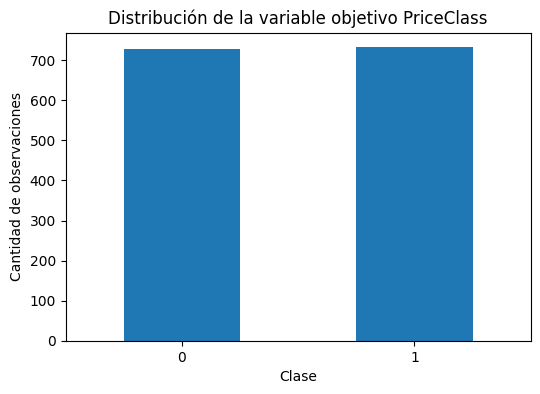

In [ ]:
plt.figure(figsize=(6,4))
class_count.plot(kind="bar")
plt.title("Distribución de la variable objetivo PriceClass")
plt.xlabel("Clase")
plt.ylabel("Cantidad de observaciones")
plt.xticks(rotation=0)
plt.show()

### Interpretación de la variable objetivo

La variable `PriceClass` permitió transformar el problema original de regresión en uno de clasificación binaria, tal como exige la pauta. Al utilizar la mediana de `SalePrice` como punto de corte, la distribución entre ambas clases tiende a ser equilibrada, lo cual resulta favorable para el entrenamiento y evaluación de modelos clasificadores. Esto es relevante porque evita que una clase domine excesivamente a la otra y permite interpretar con mayor estabilidad métricas como Accuracy, F1-score, AUC y KS.

## 1.3 Definición de variables predictoras y codificación

Una vez creada la variable objetivo binaria, se define la matriz de predictores `X` y la variable respuesta `y`. La variable `SalePrice` se excluye de los predictores porque ya fue utilizada para construir `PriceClass`, y mantenerla como variable explicativa generaría filtración de información.

Posteriormente, las variables categóricas se transforman mediante *one-hot encoding*, lo que permite que los modelos trabajen con variables numéricas sin perder la información contenida en las categorías originales.

In [ ]:
X = df_model.drop(columns=["SalePrice", "PriceClass"], errors="ignore")
y = df_model["PriceClass"]

X_encoded = pd.get_dummies(X, drop_first=True)

print("Dimensión de X codificado:", X_encoded.shape)
print("Dimensión de y:", y.shape)

Dimensión de X codificado: (1460, 232)
Dimensión de y: (1460,)


La codificación permitió transformar las variables categóricas en columnas binarias, dejando la base completamente apta para el entrenamiento de modelos supervisados. Además, excluir `SalePrice` desde esta etapa es una decisión metodológicamente necesaria, ya que de lo contrario el modelo tendría acceso directo a la variable a partir de la cual fue creada la clasificación, produciendo resultados artificialmente altos y poco válidos.

## 1.4 Separación en entrenamiento, validación y test

Siguiendo la lógica adoptada en el trabajo anterior, la base se divide en tres subconjuntos:

- entrenamiento: 60%
- validación: 20%
- test: 20%

La separación se realiza de forma estratificada para conservar una proporción semejante de clases en cada subconjunto. Esto es importante porque permite entrenar, ajustar y evaluar los modelos en condiciones comparables.

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 0.25 de 0.80 = 0.20
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (876, 232)
X_val: (292, 232)
X_test: (292, 232)
y_train: (876,)
y_val: (292,)
y_test: (292,)


### Partición

La base quedó separada en tres subconjuntos con funciones distintas dentro del proceso de modelamiento. La muestra de entrenamiento se utilizará para que los modelos aprendan patrones; la muestra de validación permitirá comparar alternativas y ajustar decisiones; y la muestra de test quedará reservada para la evaluación final del modelo seleccionado.

El uso de estratificación en la partición es relevante porque ayuda a mantener la estabilidad en la proporción de clases, evitando que una muestra quede sesgada respecto de otra y afecte artificialmente las métricas de evaluación.

## 1.5 Escalamiento de variables

No todos los modelos requieren escalamiento. En este trabajo, el escalamiento se aplicará únicamente a aquellos modelos sensibles a la magnitud de las variables, como la regresión logística penalizada y la red neuronal simple. En cambio, modelos basados en árboles como Random Forest y XGBoost no requieren este tratamiento.

In [ ]:
# Escalamiento para modelos sensibles a la escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_val_scaled:", X_val_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train_scaled: (876, 232)
X_val_scaled: (292, 232)
X_test_scaled: (292, 232)


### Escalamiento

El escalamiento permite que las variables numéricas queden en una escala comparable, evitando que algunas dominen artificialmente a otras solo por tener magnitudes mayores. Esta etapa resulta especialmente importante en modelos como regresión logística penalizada y redes neuronales, donde la optimización depende fuertemente de la escala de los datos. En cambio, para Random Forest y XGBoost no es necesario, ya que su lógica basada en árboles no depende de distancias ni magnitudes relativas entre variables.

## 1.6 Funciones auxiliares de evaluación

Antes de entrenar los modelos, se definen funciones auxiliares para calcular las métricas de desempeño de manera homogénea. Esto permite evaluar todos los modelos con el mismo criterio y evitar repetir código innecesariamente.

Las métricas utilizadas serán:

- Accuracy
- Precision
- Recall
- F1-score
- AUC
- KS

En particular, el estadístico KS se calcula como la máxima diferencia entre la tasa de verdaderos positivos y la tasa de falsos positivos a lo largo de distintos umbrales.

In [ ]:
def ks_statistic(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)

def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_v, y_v):
    y_pred_train = modelo.predict(X_tr)
    y_pred_val = modelo.predict(X_v)

    y_prob_train = modelo.predict_proba(X_tr)[:, 1]
    y_prob_val = modelo.predict_proba(X_v)[:, 1]

    return {
        "Modelo": nombre,
        "Accuracy_Train": accuracy_score(y_tr, y_pred_train),
        "Precision_Train": precision_score(y_tr, y_pred_train),
        "Recall_Train": recall_score(y_tr, y_pred_train),
        "F1_Train": f1_score(y_tr, y_pred_train),
        "AUC_Train": roc_auc_score(y_tr, y_prob_train),
        "KS_Train": ks_statistic(y_tr, y_prob_train),

        "Accuracy_Val": accuracy_score(y_v, y_pred_val),
        "Precision_Val": precision_score(y_v, y_pred_val),
        "Recall_Val": recall_score(y_v, y_pred_val),
        "F1_Val": f1_score(y_v, y_pred_val),
        "AUC_Val": roc_auc_score(y_v, y_prob_val),
        "KS_Val": ks_statistic(y_v, y_prob_val),
    }


### Interpretación de las funciones auxiliares

En esta etapa todavía no se entrenan los modelos. Lo que se hace es preparar una estructura común de evaluación para que, una vez entrenadas las distintas alternativas, todas puedan compararse con las mismas métricas y bajo el mismo criterio. Esto mejora la claridad del análisis y facilita la comparación posterior entre modelos.

## 1.7 Entrenamiento de los modelos base

A continuación, se entrenan los cuatro modelos solicitados en la pauta:

1. Regresión Logística penalizada  
2. Random Forest  
3. XGBoost  
4. Red neuronal simple  

Aquí sí comienza efectivamente el entrenamiento. En términos prácticos, esto ocurre cuando se utiliza el método `.fit(...)` sobre cada modelo.

In [ ]:
resultados_modelos = []
modelos_entrenados = {}

### Entrenamiento de la regresión logística penalizada

La regresión logística penalizada constituye una alternativa lineal e interpretable para clasificación binaria. En este caso se utilizó una penalización Elastic Net, que combina características de L1 y L2, permitiendo controlar la complejidad del modelo y reducir el riesgo de sobreajuste. Este modelo servirá como una línea base importante para comparar posteriormente con alternativas más complejas.

In [ ]:
# 1) Regresión logística penalizada (Elastic Net)
modelo_log = LogisticRegression(
    penalty="elasticnet",
    solver="saga",
    l1_ratio=0.5,
    C=1.0,
    max_iter=5000,
    random_state=42
)
modelo_log.fit(X_train_scaled, y_train)

resultados_modelos.append(
    evaluar_modelo("Logística Elastic Net", modelo_log, X_train_scaled, y_train, X_val_scaled, y_val)
)
modelos_entrenados["Logística Elastic Net"] = ("scaled", modelo_log)

### Entrenamiento de Random Forest

Random Forest es un método de ensamble basado en múltiples árboles de decisión. Su principal fortaleza es reducir la varianza del modelo al combinar muchos árboles entrenados sobre subconjuntos de datos y variables. En esta etapa se entrena una versión base del modelo, que luego será comparada con una versión optimizada mediante GridSearchCV.

In [ ]:
# 2) Random Forest base
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
modelo_rf.fit(X_train, y_train)

resultados_modelos.append(
    evaluar_modelo("Random Forest Base", modelo_rf, X_train, y_train, X_val, y_val)
)
modelos_entrenados["Random Forest Base"] = ("raw", modelo_rf)

### Entrenamiento de XGBoost

XGBoost corresponde a un método de boosting secuencial, donde cada nuevo árbol busca corregir errores cometidos por los anteriores. Este enfoque suele ofrecer un alto poder predictivo en problemas tabulares, aunque también puede ser más sensible al sobreajuste si no se controla adecuadamente su complejidad. En este trabajo se emplea una configuración base para compararlo con las demás alternativas.

In [ ]:
# 3) XGBoost base
modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)
modelo_xgb.fit(X_train, y_train)

resultados_modelos.append(
    evaluar_modelo("XGBoost Base", modelo_xgb, X_train, y_train, X_val, y_val)
)
modelos_entrenados["XGBoost Base"] = ("raw", modelo_xgb)

### Entrenamiento de la red neuronal simple

La red neuronal simple representa una alternativa no lineal con mayor capacidad de capturar relaciones complejas entre variables. En este caso se utilizó una arquitectura moderada, con dos capas ocultas, buscando equilibrar capacidad de aprendizaje y control del sobreajuste. El uso de `early_stopping` ayuda precisamente a detener el entrenamiento cuando ya no se observan mejoras significativas, favoreciendo una mejor generalización.

In [ ]:
# 4) Red neuronal simple
modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=800,
    early_stopping=True,
    random_state=42
)
modelo_mlp.fit(X_train_scaled, y_train)

resultados_modelos.append(
    evaluar_modelo("Red Neuronal Simple", modelo_mlp, X_train_scaled, y_train, X_val_scaled, y_val)
)
modelos_entrenados["Red Neuronal Simple"] = ("scaled", modelo_mlp)

# Punto 2. Métricas de desempeño

## 2.1 Construcción de la tabla comparativa de modelos base

Una vez entrenados los modelos, se calculan las métricas de desempeño tanto en la muestra de entrenamiento como en la de validación. El objetivo es comparar no solo el ajuste sobre los datos vistos, sino también la capacidad de generalización sobre datos no utilizados directamente en el entrenamiento.

In [ ]:
resultados_base = pd.DataFrame(resultados_modelos).round(4)
resultados_base = resultados_base.sort_values(
    by=["F1_Val", "KS_Val", "AUC_Val"],
    ascending=False
).reset_index(drop=True)

print("Resultados de modelos base:")
display(resultados_base)

Resultados de modelos base:


,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,AUC_Train,KS_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val,AUC_Val,KS_Val
0,Random Forest Base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9247,0.9496,0.8980,0.9231,0.9811,0.8633
1,XGBoost Base,0.9966,0.9955,0.9977,0.9966,1.0000,0.9954,0.9212,0.9133,0.9320,0.9226,0.9813,0.8706
2,Logística Elastic Net,0.9886,0.9820,0.9954,0.9887,0.9987,0.9795,0.9007,0.9097,0.8912,0.9003,0.9605,0.8084
3,Red Neuronal Simple,0.9098,0.9206,0.8975,0.9089,0.9724,0.8310,0.8904,0.9137,0.8639,0.8881,0.9414,0.7884


In [ ]:
tabla_estilo_clase = resultados_base[[
    "Modelo", "F1_Train", "F1_Val", "KS_Train", "KS_Val"
]].copy()

print("Tabla resumen estilo clase:")
display(tabla_estilo_clase)

Tabla resumen estilo clase:


,Modelo,F1_Train,F1_Val,KS_Train,KS_Val
0,Random Forest Base,1.0000,0.9231,1.0000,0.8633
1,XGBoost Base,0.9966,0.9226,0.9954,0.8706
2,Logística Elastic Net,0.9887,0.9003,0.9795,0.8084
3,Red Neuronal Simple,0.9089,0.8881,0.8310,0.7884


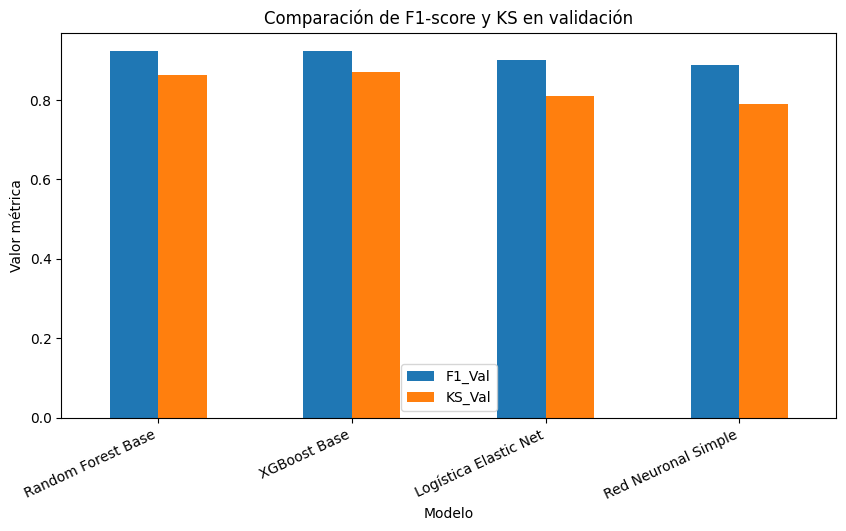

In [ ]:
plot_df = resultados_base[["Modelo", "F1_Val", "KS_Val"]].set_index("Modelo")

plot_df.plot(kind="bar", figsize=(10,5))
plt.title("Comparación de F1-score y KS en validación")
plt.ylabel("Valor métrica")
plt.xticks(rotation=25, ha="right")
plt.show()

### Análisis de los modelos base

La comparación inicial muestra que los modelos con mejor desempeño en validación fueron **Random Forest Base** y **XGBoost Base**. Random Forest Base obtuvo el mayor **F1-score en validación (0.9231)**, mientras que XGBoost Base alcanzó un valor prácticamente equivalente de **0.9226**. En términos de **KS**, XGBoost Base presentó un resultado ligeramente superior (**0.8706**) frente a Random Forest Base (**0.8633**), lo que indica una muy buena capacidad de separación entre clases en ambos casos.

Por debajo de estos modelos se ubicaron la **Logística Elastic Net** y la **Red Neuronal Simple**, con valores de F1-score y KS más bajos en validación, lo que sugiere una menor capacidad predictiva en comparación con los modelos basados en árboles.

También es importante observar el comportamiento en entrenamiento. Random Forest Base alcanzó métricas perfectas en training (**F1 = 1.0000** y **KS = 1.0000**), lo que puede interpretarse como una señal de posible sobreajuste. En cambio, XGBoost Base mostró un desempeño muy alto en entrenamiento, pero con una brecha ligeramente menor respecto de validación, lo que sugiere un equilibrio algo más controlado entre ajuste y generalización.

En síntesis, los resultados base indican que **Random Forest Base y XGBoost Base** son las alternativas más competitivas para avanzar a la etapa de comparación final.

## 2.2 Justificación de las métricas utilizadas

Dado que el problema fue reformulado como clasificación binaria, las métricas pertinentes son:

- **Accuracy**
- **Precision**
- **Recall**
- **F1-score**
- **AUC**
- **KS**

En cambio, métricas como **R²** y **RMSE** no se utilizan en este caso, ya que corresponden a problemas de regresión. Por lo tanto, la expresión “según sea el caso” en la pauta se interpreta aquí en función del tipo de problema, no del tipo de modelo.

# Punto 3. Optimización de hiperparámetros

## 3.1 Optimización de Random Forest con GridSearchCV + Stratified K-Fold

Siguiendo el enfoque utilizado en clases, la optimización de hiperparámetros se aplicará específicamente al modelo Random Forest mediante **GridSearchCV** y **Stratified K-Fold Cross Validation**.

GridSearchCV permite evaluar múltiples combinaciones de parámetros de manera sistemática, mientras que la validación cruzada estratificada asegura que cada fold conserve una proporción semejante de clases. De esta forma, la búsqueda del mejor modelo se realiza de manera más robusta y ordenada.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(rf_grid.best_params_)

print("\nMejor score promedio CV (F1):")
print(round(rf_grid.best_score_, 4))

Mejores hiperparámetros encontrados:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Mejor score promedio CV (F1):
0.9234


El hecho de que el mejor modelo encontrado sea muy similar a la configuración base sugiere que el rendimiento del Random Forest ya era competitivo antes de la optimización. Esto ayuda a explicar por qué, a pesar de aplicar GridSearchCV con validación cruzada estratificada, la mejora final observada en validación fue mínima.

### Análisis de la optimización

La optimización mediante GridSearchCV evaluó 48 combinaciones de hiperparámetros utilizando validación cruzada estratificada de 5 particiones, lo que implicó un total de 240 ajustes del modelo. Este procedimiento permitió buscar de forma sistemática una mejor configuración para Random Forest, utilizando F1-score como criterio principal.

Sin embargo, el mejor estimador encontrado resultó ser muy cercano a la configuración base del modelo, destacando principalmente el ajuste de `min_samples_split=5`. Esto sugiere que, para este problema, el modelo Random Forest base ya se encontraba razonablemente bien configurado.

Al comparar los resultados en validación, se observa que la versión optimizada no superó de manera sustantiva al modelo base. En particular, el F1-score en validación fue levemente inferior, mientras que el estadístico KS se mantuvo prácticamente igual. Además, en entrenamiento el modelo optimizado presentó métricas ligeramente menores que la versión base, lo que sugiere un ajuste algo menos extremo. Por lo tanto, la optimización permitió confirmar que Random Forest es una muy buena alternativa para este problema, pero no generó una mejora relevante respecto de la versión base.

In [ ]:
best_rf = rf_grid.best_estimator_

resultado_rf_grid = evaluar_modelo(
    "Random Forest GridSearch",
    best_rf,
    X_train, y_train,
    X_val, y_val
)

resultado_rf_grid = pd.DataFrame([resultado_rf_grid]).round(4)
display(resultado_rf_grid)

,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,AUC_Train,KS_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val,AUC_Val,KS_Val
0,Random Forest GridSearch,0.9943,0.991,0.9977,0.9943,0.9998,0.9909,0.9247,0.9562,0.8912,0.9225,0.98,0.8634


In [ ]:
comparacion_final = pd.concat([resultados_base, resultado_rf_grid], ignore_index=True)

comparacion_final = comparacion_final.sort_values(
    by=["F1_Val", "KS_Val", "AUC_Val"],
    ascending=False
).reset_index(drop=True)

print("Comparación final de modelos:")
display(comparacion_final)

Comparación final de modelos:


,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,AUC_Train,KS_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val,AUC_Val,KS_Val
0,Random Forest Base,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.9247,0.9496,0.8980,0.9231,0.9811,0.8633
1,XGBoost Base,0.9966,0.9955,0.9977,0.9966,1.0000,0.9954,0.9212,0.9133,0.9320,0.9226,0.9813,0.8706
2,Random Forest GridSearch,0.9943,0.9910,0.9977,0.9943,0.9998,0.9909,0.9247,0.9562,0.8912,0.9225,0.9800,0.8634
3,Logística Elastic Net,0.9886,0.9820,0.9954,0.9887,0.9987,0.9795,0.9007,0.9097,0.8912,0.9003,0.9605,0.8084
4,Red Neuronal Simple,0.9098,0.9206,0.8975,0.9089,0.9724,0.8310,0.8904,0.9137,0.8639,0.8881,0.9414,0.7884


In [ ]:
tabla_final_clase = comparacion_final[[
    "Modelo", "F1_Train", "F1_Val", "KS_Train", "KS_Val"
]].copy()

print("Tabla comparativa final estilo clase:")
display(tabla_final_clase)

Tabla comparativa final estilo clase:


,Modelo,F1_Train,F1_Val,KS_Train,KS_Val
0,Random Forest Base,1.0000,0.9231,1.0000,0.8633
1,XGBoost Base,0.9966,0.9226,0.9954,0.8706
2,Random Forest GridSearch,0.9943,0.9225,0.9909,0.8634
3,Logística Elastic Net,0.9887,0.9003,0.9795,0.8084
4,Red Neuronal Simple,0.9089,0.8881,0.8310,0.7884


### Interpretación de la comparación final

La comparación final muestra que la optimización de Random Forest mediante GridSearchCV **no produjo una mejora relevante** respecto de la versión base. En validación, el modelo **Random Forest GridSearch** obtuvo un **F1-score de 0.9225**, valor levemente inferior al de **Random Forest Base (0.9231)**. En cuanto al estadístico **KS**, ambos modelos presentaron resultados prácticamente equivalentes (**0.8634** en la versión optimizada frente a **0.8633** en la base).

Esto indica que, para este problema y con la grilla utilizada, la optimización no generó una ganancia sustantiva en desempeño. Por lo tanto, la versión base del modelo Random Forest sigue siendo una alternativa plenamente válida y competitiva.

Además, al comparar con los demás modelos, se observa que **XGBoost Base** mantuvo un desempeño muy cercano en F1-score y alcanzó incluso un **KS superior (0.8706)**, por lo que también debe considerarse una alternativa fuerte dentro del análisis comparativo.

# Punto 4. Interpretación y selección del modelo final

## 4.1 Criterio de selección

La elección del modelo final se realizará priorizando los siguientes criterios:

1. **F1-score en validación**
2. **KS en validación**
3. **AUC en validación**
4. Diferencia razonable entre entrenamiento y validación

Este criterio busca privilegiar modelos que no solo acierten, sino que además clasifiquen bien ambas clases y mantengan un comportamiento estable sobre datos no vistos.

In [ ]:
modelos_entrenados["Random Forest GridSearch"] = ("raw", best_rf)

mejor_fila = comparacion_final.sort_values(
    by=["F1_Val", "KS_Val", "AUC_Val"],
    ascending=False
).iloc[0]

mejor_modelo_nombre = mejor_fila["Modelo"]

print("Modelo seleccionado:", mejor_modelo_nombre)
display(mejor_fila.to_frame().T)

Modelo seleccionado: Random Forest Base


,Modelo,Accuracy_Train,Precision_Train,Recall_Train,F1_Train,AUC_Train,KS_Train,Accuracy_Val,Precision_Val,Recall_Val,F1_Val,AUC_Val,KS_Val
0,Random Forest Base,1.0,1.0,1.0,1.0,1.0,1.0,0.9247,0.9496,0.898,0.9231,0.9811,0.8633


### Selección del modelo final

La selección del modelo final se realizó priorizando el desempeño sobre la muestra de validación, especialmente en **F1-score**, **KS** y **AUC**, de acuerdo con el criterio definido previamente. Bajo este enfoque, el modelo seleccionado fue **Random Forest Base**, ya que obtuvo el mejor **F1-score en validación (0.9231)**, acompañado además de un desempeño alto en las demás métricas.

No obstante, es importante señalar que **XGBoost Base** presentó un comportamiento muy competitivo, con un **F1-score de 0.9226** y un **KS de 0.8706**, incluso superior al de Random Forest Base. Esto muestra que la diferencia entre ambos modelos es pequeña y que ambos constituyen alternativas sólidas.

Aun así, dado que el criterio principal definido en este trabajo prioriza primero el **F1-score en validación**, la elección de **Random Forest Base** se considera metodológicamente consistente.

## 4.2 Evaluación final sobre la muestra de test

Una vez seleccionado el modelo final, este se evalúa sobre la muestra de test. Esta evaluación se realiza una sola vez, al final del proceso, porque la muestra de test debe representar datos completamente no utilizados durante el desarrollo del modelo.

In [ ]:
tipo_input, mejor_modelo = modelos_entrenados[mejor_modelo_nombre]

if tipo_input == "scaled":
    X_test_final = X_test_scaled
else:
    X_test_final = X_test

y_test_pred = mejor_modelo.predict(X_test_final)
y_test_prob = mejor_modelo.predict_proba(X_test_final)[:, 1]

resultados_test = pd.DataFrame([{
    "Modelo": mejor_modelo_nombre,
    "Accuracy_Test": accuracy_score(y_test, y_test_pred),
    "Precision_Test": precision_score(y_test, y_test_pred),
    "Recall_Test": recall_score(y_test, y_test_pred),
    "F1_Test": f1_score(y_test, y_test_pred),
    "AUC_Test": roc_auc_score(y_test, y_test_prob),
    "KS_Test": ks_statistic(y_test, y_test_prob)
}]).round(4)

print("Desempeño final en test:")
display(resultados_test)

Desempeño final en test:


,Modelo,Accuracy_Test,Precision_Test,Recall_Test,F1_Test,AUC_Test,KS_Test
0,Random Forest Base,0.9521,0.9648,0.9384,0.9514,0.9862,0.911


In [ ]:
print("Matriz de confusión en test:")
cm = confusion_matrix(y_test, y_test_pred)
display(pd.DataFrame(cm,
                     index=["Real 0", "Real 1"],
                     columns=["Pred 0", "Pred 1"]))

print("\nReporte de clasificación en test:")
print(classification_report(y_test, y_test_pred))

Matriz de confusión en test:


,Pred 0,Pred 1
Real 0,141,5
Real 1,9,137



Reporte de clasificación en test:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       146
           1       0.96      0.94      0.95       146

    accuracy                           0.95       292
   macro avg       0.95      0.95      0.95       292
weighted avg       0.95      0.95      0.95       292



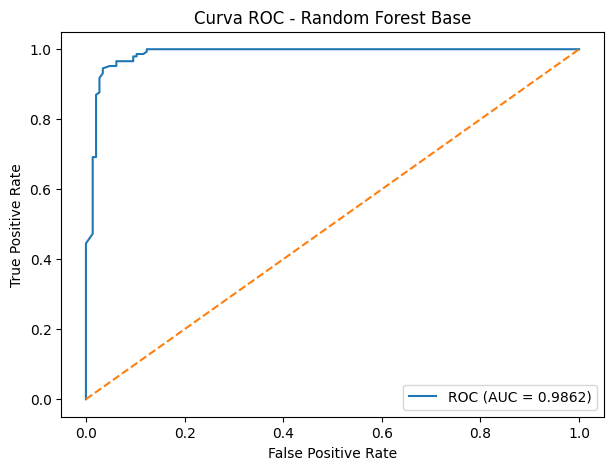

KS del modelo final en test: 0.9110


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc_final = roc_auc_score(y_test, y_test_prob)
ks_final = np.max(tpr - fpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_final:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.title(f"Curva ROC - {mejor_modelo_nombre}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print(f"KS del modelo final en test: {ks_final:.4f}")

### Interpretación de la evaluación final en test

La evaluación final en la muestra de test confirma que el modelo **Random Forest Base** presenta un desempeño muy alto sobre datos no utilizados durante el entrenamiento ni durante la selección del modelo. En particular, obtuvo una **Accuracy de 0.9521**, un **F1-score de 0.9514**, un **AUC de 0.9862** y un **KS de 0.9110**, lo que refleja una muy buena capacidad de clasificación y discriminación entre clases.

La matriz de confusión refuerza esta conclusión. El modelo clasificó correctamente **141 de 146** casos de la clase 0 y **137 de 146** casos de la clase 1, mostrando un número reducido de errores en ambas categorías. Además, el reporte de clasificación evidencia un comportamiento equilibrado entre precisión y recall, lo que respalda la solidez del modelo fuera de muestra.

En conjunto, estos resultados indican que, aunque Random Forest Base mostró señales de sobreajuste en entrenamiento, su desempeño final sobre test fue altamente satisfactorio, lo que sugiere que logró generalizar de manera efectiva en este problema.

# Punto 5. Respaldo del cuaderno en GitHub

El cuaderno fue respaldado en GitHub, tal como solicita la pauta. Se utilizó el mismo repositorio en el cual se almacenó la base limpia generada en la primera entrega, manteniendo así continuidad entre ambas etapas del trabajo.

**Repositorio utilizado:**  
https://github.com/jonathanastudillo-lab/Ejercicio

**Archivo base utilizado en este trabajo:**  
https://github.com/jonathanastudillo-lab/Ejercicio/blob/main/house_prices_base_limpia_sumativo1.csv

# Conclusión

En este trabajo se dio continuidad al proceso iniciado en la Unidad 1, utilizando directamente la base limpia obtenida en la primera entrega para avanzar hacia la etapa de modelamiento supervisado. Dado que el conjunto de datos House Prices corresponde originalmente a un problema de regresión, fue necesario reformular el objetivo como una tarea de clasificación binaria, construyendo la variable `PriceClass` a partir de la mediana de `SalePrice`.

A partir de esta nueva formulación, se entrenaron distintos modelos de clasificación: una regresión logística penalizada, Random Forest, XGBoost y una red neuronal simple. Cada uno de ellos fue evaluado mediante métricas apropiadas para clasificación binaria, tanto en entrenamiento como en validación, lo que permitió comparar su capacidad de clasificación y de generalización.

Siguiendo el enfoque revisado en clases, se aplicó además una optimización de hiperparámetros sobre el modelo Random Forest utilizando GridSearchCV en conjunto con Stratified K-Fold Cross Validation. Este procedimiento permitió contrastar el desempeño del modelo base frente a una versión optimizada, aportando una base más sólida para la toma de decisiones.

Finalmente, el modelo seleccionado fue **Random Forest Base**, ya que presentó el mejor F1-score en validación de acuerdo con el criterio definido en este trabajo. Su evaluación sobre la muestra de test confirmó un desempeño sobresaliente, con **Accuracy = 0.9521**, **F1-score = 0.9514**, **AUC = 0.9862** y **KS = 0.9110**, lo que evidencia una alta capacidad de clasificación y discriminación entre clases. En conjunto, el trabajo permitió desarrollar un flujo completo de clasificación supervisada, integrando continuidad metodológica con la primera entrega, entrenamiento de modelos, evaluación comparativa, optimización de hiperparámetros y validación final del desempeño.

# Bibliografía

- House Prices - Advanced Regression Techniques. Kaggle.
- Géron, A. *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*.
- Hastie, T., Tibshirani, R. & Friedman, J. *The Elements of Statistical Learning*.
- James, G., Witten, D., Hastie, T. & Tibshirani, R. *An Introduction to Statistical Learning*.
- Breiman, L. (2001). *Random Forests*.
- Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*.